# 🧠 Word Embeddings y LSTM

## Deep Learning para Análisis de Sentimientos

En este notebook implementamos un modelo LSTM con Word Embeddings usando el dataset IMDB real.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

print(f"✅ TensorFlow: {tf.__version__}")
print(f"✅ Librerías importadas")

✅ TensorFlow: 2.20.0
✅ Librerías importadas


In [17]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
MODELS_DIR = PROJECT_DIR / 'models'
REPORTS_DIR = PROJECT_DIR / 'reports'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Rutas configuradas")

📁 Rutas configuradas


## Cargar Dataset IMDB

In [18]:
print("="*70)
print("📥 CARGANDO DATASET IMDB")
print("="*70)

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

print(f"\n✅ Dataset cargado:")
print(f"   - Training: {len(X_train):,} reviews")
print(f"   - Test: {len(X_test):,} reviews")
print(f"   - Longitud promedio: {np.mean([len(x) for x in X_train]):.0f} palabras")

📥 CARGANDO DATASET IMDB

✅ Dataset cargado:
   - Training: 25,000 reviews
   - Test: 25,000 reviews
   - Longitud promedio: 239 palabras


## Preparar Datos

In [19]:
print("="*70)
print("📏 PREPARACIÓN DE DATOS")
print("="*70)

max_length = 300
embedding_dim = 64
vocab_size = 10000

print(f"\n⚙️  Parámetros OPTIMIZADOS:")
print(f"   - max_length: {max_length}")
print(f"   - embedding_dim: {embedding_dim}")
print(f"   - vocab_size: {vocab_size}")

print(f"\n⏳ Aplicando padding...")
X_train_padded = pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post')

y_train_np = np.array(y_train, dtype=np.float32)
y_test_np = np.array(y_test, dtype=np.float32)

print(f"✅ Datos preparados:")
print(f"   - X_train: {X_train_padded.shape}")
print(f"   - X_test: {X_test_padded.shape}")
print(f"   - Sin NaN: {np.isnan(X_train_padded).sum() == 0}")

📏 PREPARACIÓN DE DATOS

⚙️  Parámetros OPTIMIZADOS:
   - max_length: 300
   - embedding_dim: 64
   - vocab_size: 10000

⏳ Aplicando padding...
✅ Datos preparados:
   - X_train: (25000, 300)
   - X_test: (25000, 300)
   - Sin NaN: True


## Construir Modelo

In [20]:
print("="*70)
print("🔨 CONSTRUYENDO MODELO LSTM")
print("="*70)

tf.keras.backend.clear_session()

model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              input_length=max_length,
              mask_zero=True),
    
    LSTM(units=64,
         activation='tanh',
         recurrent_dropout=0.2,
         return_sequences=False),
    
    Dropout(0.3),
    Dense(units=32, activation='relu'),
    Dropout(0.2),
    Dense(units=1, activation='sigmoid')
], name='LSTM_Sentiment')

optimizer = Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("\n✅ Modelo compilado\n")
model.summary()

print("\n💡 Optimizaciones para evitar NaN:")
print("   ✓ Learning rate: 0.0001 (10x más bajo)")
print("   ✓ LSTM units: 64 (más pequeño)")
print("   ✓ max_length: 300 (menos memory)")

🔨 CONSTRUYENDO MODELO LSTM

✅ Modelo compilado



Model: "LSTM_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


💡 Optimizaciones para evitar NaN:
   ✓ Learning rate: 0.0001 (10x más bajo)
   ✓ LSTM units: 64 (más pequeño)
   ✓ max_length: 300 (menos memory)


## Entrenar Modelo

In [21]:
print("="*70)
print("🚀 ENTRENANDO MODELO")
print("="*70)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1,
        min_delta=0.0001
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("\n⏳ Entrenando (3-8 minutos)...\n")

history = model.fit(
    X_train_padded, y_train_np,
    batch_size=64,
    epochs=15,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1,
    shuffle=True
)

print("\n✅ Entrenamiento completado")

🚀 ENTRENANDO MODELO

⏳ Entrenando (3-8 minutos)...

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 154ms/step - accuracy: 0.5470 - loss: 0.6909 - precision: 0.5371 - recall: 0.7018 - val_accuracy: 0.7038 - val_loss: 0.6689 - val_precision: 0.6675 - val_recall: 0.7975 - learning_rate: 1.0000e-04
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 175ms/step - accuracy: 0.7478 - loss: 0.5947 - precision: 0.7385 - recall: 0.7696 - val_accuracy: 0.8134 - val_loss: 0.4933 - val_precision: 0.8787 - val_recall: 0.7217 - learning_rate: 1.0000e-04
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 175ms/step - accuracy: 0.8059 - loss: 0.5202 - precision: 0.8083 - recall: 0.8035 - val_accuracy: 0.8492 - val_loss: 0.4465 - val_precision: 0.8563 - val_recall: 0.8348 - learning_rate: 1.0000e-04
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 175ms/step - accuracy: 0.8406 - loss: 0.4570 - precision: 0.8496 - recall: 0.8289 - val_accuracy: 0.8428 - val_loss: 0.4418 - val_precision: 0.8433 - val_recall: 0.8372 - learning_r

## Evaluar Modelo

In [22]:
print("="*70)
print("📊 EVALUACIÓN")
print("="*70)

test_loss, test_accuracy, test_precision, test_recall = model.evaluate(
    X_test_padded, y_test_np, verbose=0
)

y_pred_prob = model.predict(X_test_padded, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
test_f1 = f1_score(y_test_np, y_pred)
test_auc = roc_auc_score(y_test_np, y_pred_prob)

print(f"\n📈 Resultados:")
print(f"   - Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.1f}%)")
print(f"   - Precision: {test_precision:.4f}")
print(f"   - Recall:    {test_recall:.4f}")
print(f"   - F1-Score:  {test_f1:.4f}")
print(f"   - AUC-ROC:   {test_auc:.4f}")
print(f"   - Loss:      {test_loss:.4f}")

if test_accuracy > 0.80 and not np.isnan(test_loss):
    print(f"\n✅ MODELO ENTRENADO EXITOSAMENTE")
else:
    print(f"\n⚠️ Revisa el entrenamiento")

📊 EVALUACIÓN

📈 Resultados:
   - Accuracy:  0.8580 (85.8%)
   - Precision: 0.8680
   - Recall:    0.8444
   - F1-Score:  0.8560
   - AUC-ROC:   0.9330
   - Loss:      0.3367

✅ MODELO ENTRENADO EXITOSAMENTE


## Visualizaciones

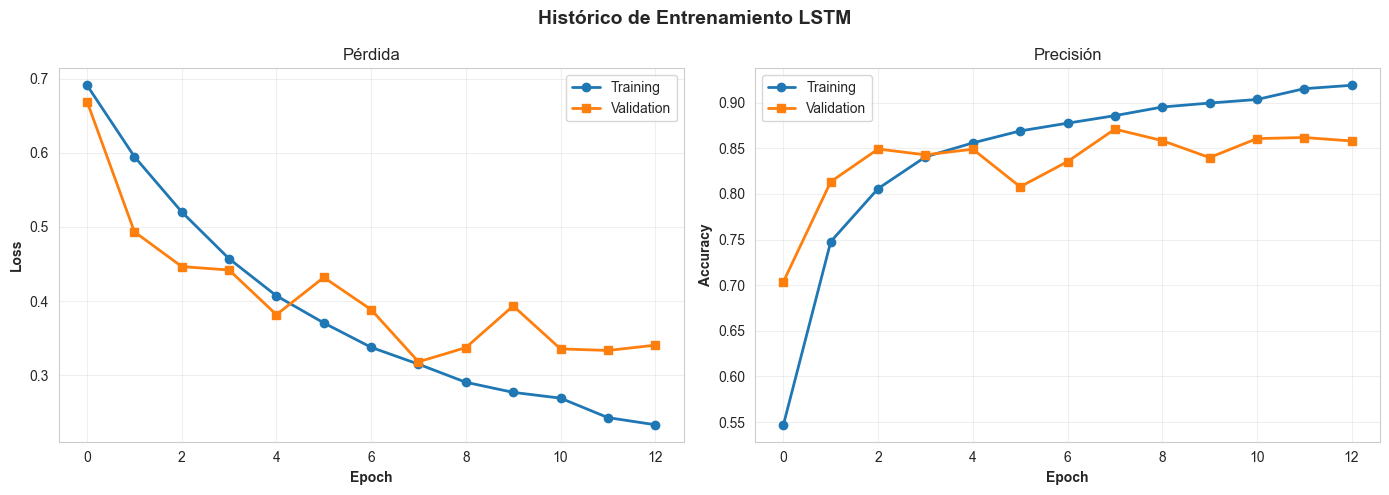

✅ Gráfico guardado


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Histórico de Entrenamiento LSTM', fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'], label='Training', linewidth=2, marker='o')
axes[0].plot(history.history['val_loss'], label='Validation', linewidth=2, marker='s')
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Loss', fontweight='bold')
axes[0].set_title('Pérdida')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training', linewidth=2, marker='o')
axes[1].plot(history.history['val_accuracy'], label='Validation', linewidth=2, marker='s')
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('Accuracy', fontweight='bold')
axes[1].set_title('Precisión')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'lstm_training.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado")

## Guardar Modelo

In [24]:
model_path = MODELS_DIR / 'lstm_sentiment_model.keras'
model.save(str(model_path))

print(f"✅ Modelo guardado: {model_path.name}")

import json
config = {
    'vocab_size': vocab_size,
    'embedding_dim': embedding_dim,
    'max_length': max_length,
    'accuracy': float(test_accuracy),
    'f1_score': float(test_f1),
    'auc_roc': float(test_auc)
}

config_path = MODELS_DIR / 'lstm_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f"✅ Configuración guardada")

✅ Modelo guardado: lstm_sentiment_model.keras
✅ Configuración guardada
